<a href="https://colab.research.google.com/github/EvADarya/Data_processing-DLS-/blob/main/ML_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn import tree
from sklearn.svm import LinearSVC

In [8]:
df = pd.read_csv('/content/star_classification.csv')

In [9]:
df['class'].value_counts()

,count
class,
GALAXY,59445
STAR,21594
QSO,18961


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [11]:
classes = pd.DataFrame()
classes = pd.get_dummies(df['class'],dtype = int)

In [12]:
df = pd.concat([classes,df], axis = 1)

In [13]:
df.drop_duplicates()

,GALAXY,QSO,STAR,obj_ID,alpha,delta,u,g,r,i,...,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1,0,0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,...,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1,0,0,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,...,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1,0,0,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,...,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1,0,0,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,...,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1,0,0,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,...,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,0,0,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,...,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1,0,0,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,...,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1,0,0,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,...,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1,0,0,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,...,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   GALAXY       100000 non-null  int64  
 1   QSO          100000 non-null  int64  
 2   STAR         100000 non-null  int64  
 3   obj_ID       100000 non-null  float64
 4   alpha        100000 non-null  float64
 5   delta        100000 non-null  float64
 6   u            100000 non-null  float64
 7   g            100000 non-null  float64
 8   r            100000 non-null  float64
 9   i            100000 non-null  float64
 10  z            100000 non-null  float64
 11  run_ID       100000 non-null  int64  
 12  rerun_ID     100000 non-null  int64  
 13  cam_col      100000 non-null  int64  
 14  field_ID     100000 non-null  int64  
 15  spec_obj_ID  100000 non-null  float64
 16  class        100000 non-null  object 
 17  redshift     100000 non-null  float64
 18  plate        100000 non-n

In [15]:
df.drop('rerun_ID', axis = 1, inplace = True)

<Axes: >

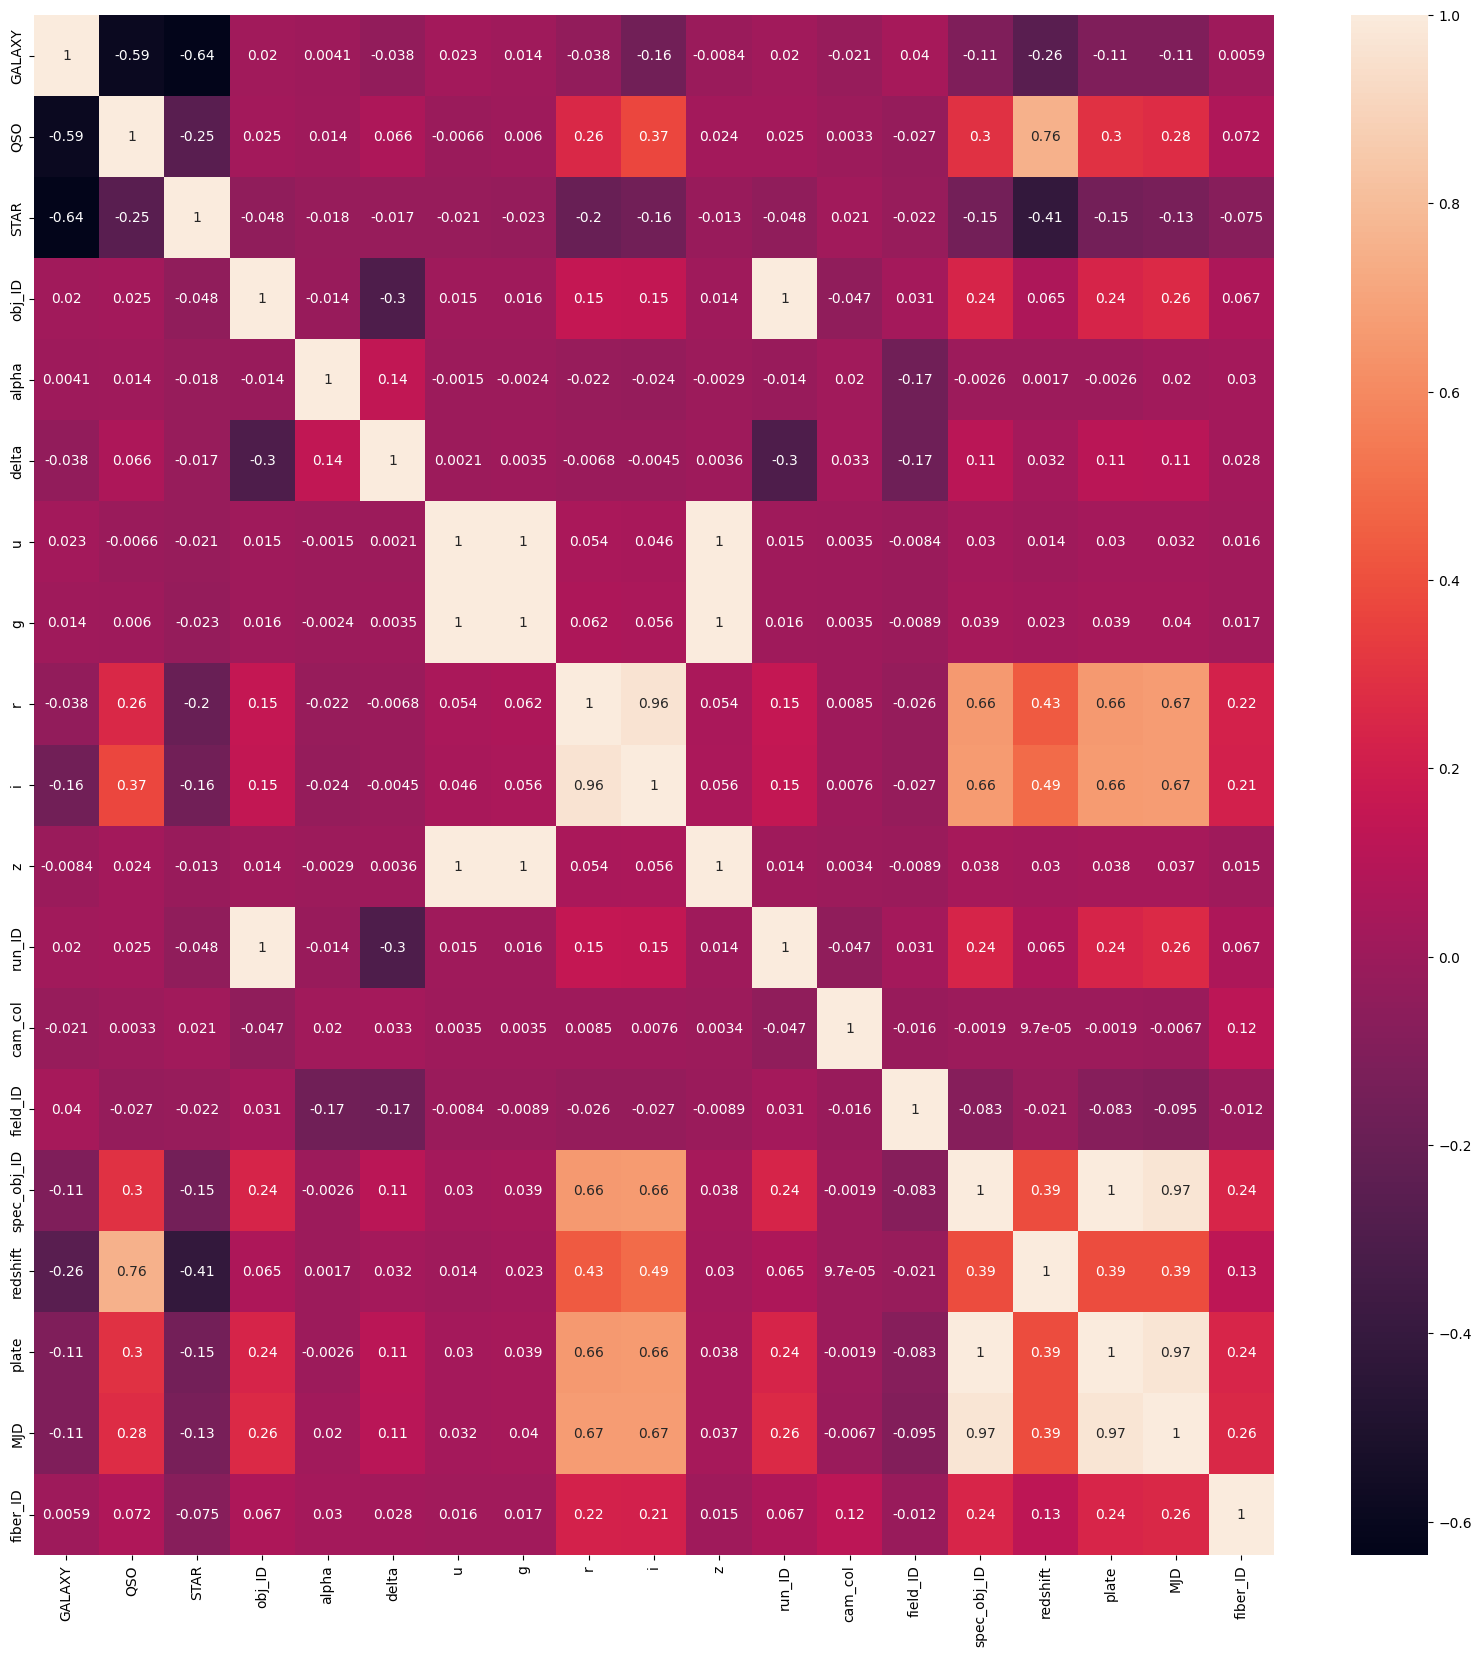

In [16]:
corrmatrix = df.drop('class', axis = 1,inplace = False).corr()
plt.figure(figsize = (20,20))
sns.heatmap(corrmatrix, annot= True)


In [17]:
#sns.set()
#sns.pairplot(df, height = 2 ,kind ='scatter',diag_kind='kde') # взаимные графики на куче признаков
#plt.show()

<Axes: ylabel='cam_col'>

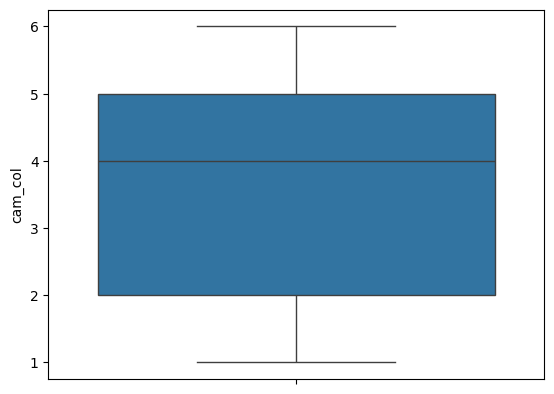

In [18]:
sns.boxplot(df['cam_col'])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   GALAXY       100000 non-null  int64  
 1   QSO          100000 non-null  int64  
 2   STAR         100000 non-null  int64  
 3   obj_ID       100000 non-null  float64
 4   alpha        100000 non-null  float64
 5   delta        100000 non-null  float64
 6   u            100000 non-null  float64
 7   g            100000 non-null  float64
 8   r            100000 non-null  float64
 9   i            100000 non-null  float64
 10  z            100000 non-null  float64
 11  run_ID       100000 non-null  int64  
 12  cam_col      100000 non-null  int64  
 13  field_ID     100000 non-null  int64  
 14  spec_obj_ID  100000 non-null  float64
 15  class        100000 non-null  object 
 16  redshift     100000 non-null  float64
 17  plate        100000 non-null  int64  
 18  MJD          100000 non-n

In [20]:
lof = LocalOutlierFactor()
outliners_index = lof.fit_predict(df.drop('class',axis = 1,inplace = False))
outliners = df[outliners_index == -1]

In [21]:
df.drop(outliners.index, axis = 0, inplace=True)

In [22]:
df.drop(['z','MJD'], axis = 1,inplace = True)

In [23]:
x = df.drop('class', axis = 1).values
y = df['class'].values

In [24]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,shuffle= True)

In [25]:
model_1 = KNeighborsClassifier()
model_2 = DecisionTreeClassifier(random_state=44)
model_2.fit(x_train, y_train)



DecisionTreeClassifier(random_state=44)

In [26]:
plt.figure(figsize=(15, 10))
tree.plot_tree(model_2)
plt.savefig('decision_tree.pdf', bbox_inches='tight')
plt.close()

In [27]:
model_1.fit(x_train,y_train)

KNeighborsClassifier()

In [28]:
from sklearn.metrics import classification_report
report_2 = classification_report(y_test, model_2.predict(x_test))
print(report_2)

              precision    recall  f1-score   support

      GALAXY       1.00      1.00      1.00     10144
         QSO       1.00      1.00      1.00      3210
        STAR       1.00      1.00      1.00      3595

    accuracy                           1.00     16949
   macro avg       1.00      1.00      1.00     16949
weighted avg       1.00      1.00      1.00     16949



In [29]:
report_1 = classification_report(y_test, model_1.predict(x_test))
print(report_1)

              precision    recall  f1-score   support

      GALAXY       0.74      0.88      0.81     10144
         QSO       0.49      0.41      0.44      3210
        STAR       0.75      0.46      0.57      3595

    accuracy                           0.70     16949
   macro avg       0.66      0.58      0.61     16949
weighted avg       0.70      0.70      0.69     16949



In [30]:
param_grid = {
    'n_neighbors': [2,3,4,5,6]
}

gridsearch = GridSearchCV(model_1, param_grid, refit=True, scoring='accuracy')

# запустим поиск
gridsearch.fit(x_train, y_train)

# выведем наилучшие параметры
print(gridsearch.best_params_)

best_model = gridsearch.best_estimator_

{'n_neighbors': 6}


In [31]:
param_grid_tree = {
    'max_depth' : [10,15,20],
    'criterion' : ['gini', 'entropy', 'log_loss']
}
gridsearch_tree = GridSearchCV(model_2, param_grid_tree, refit=True, scoring='accuracy')

gridsearch_tree.fit(x_train, y_train)

best_model_tree = gridsearch_tree.best_estimator_

{'n_neighbors': 6}


In [32]:
print(gridsearch_tree.best_params_)

{'criterion': 'gini', 'max_depth': 10}


<Figure size 600x600 with 0 Axes>

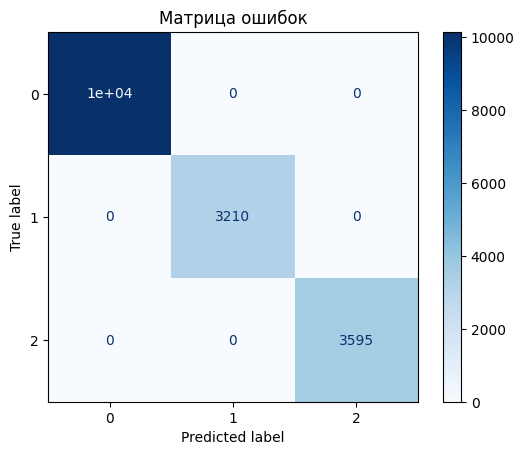

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model_tree.predict(x_test)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Визуализация
plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Матрица ошибок Desision tree')
plt.show()

<Figure size 600x600 with 0 Axes>

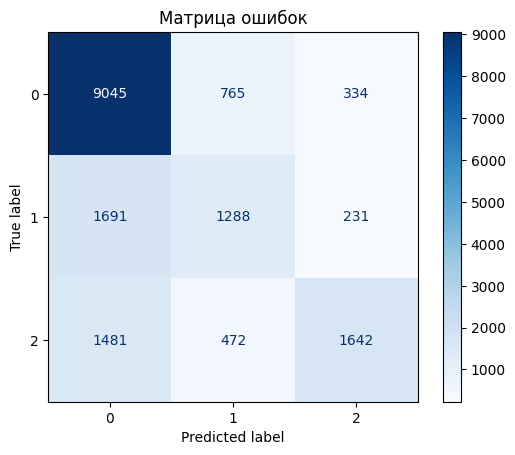

In [43]:
y_pred = best_model.predict(x_test)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Визуализация
plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Матрица ошибок K-neighbors')
plt.show()

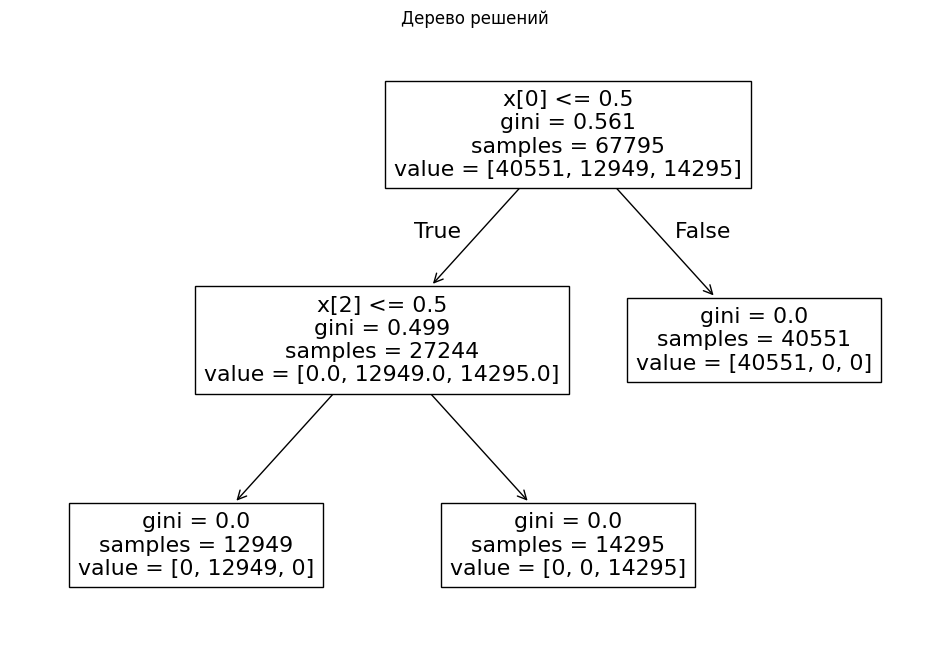

In [36]:
plt.figure(figsize=(12, 8))
tree.plot_tree(gridsearch_tree.best_estimator_)
plt.title("Дерево решений")
plt.show()

In [37]:
report_3 = classification_report(y_test, best_model.predict(x_test))
print(report_3)

              precision    recall  f1-score   support

      GALAXY       0.74      0.89      0.81     10144
         QSO       0.51      0.40      0.45      3210
        STAR       0.74      0.46      0.57      3595

    accuracy                           0.71     16949
   macro avg       0.66      0.58      0.61     16949
weighted avg       0.70      0.71      0.69     16949



In [38]:
report_4 = classification_report(y_test, best_model_tree.predict(x_test))
print(report_4)

              precision    recall  f1-score   support

      GALAXY       1.00      1.00      1.00     10144
         QSO       1.00      1.00      1.00      3210
        STAR       1.00      1.00      1.00      3595

    accuracy                           1.00     16949
   macro avg       1.00      1.00      1.00     16949
weighted avg       1.00      1.00      1.00     16949



In [39]:
clf = LinearSVC(random_state=0, tol=1e-5)
clf.fit(x_train,y_train)
report_5 = classification_report(y_test, clf.predict(x_test))
print(report_5)

              precision    recall  f1-score   support

      GALAXY       0.60      1.00      0.75     10144
         QSO       0.37      0.00      0.00      3210
        STAR       0.00      0.00      0.00      3595

    accuracy                           0.60     16949
   macro avg       0.32      0.33      0.25     16949
weighted avg       0.43      0.60      0.45     16949



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
